# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [61]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [62]:
# Load the prepared dataset from Phase 3
#DATA_PATH = '../data/processed/prepared_data.csv'

#df = pd.read_csv(DATA_PATH)
#print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
#df.head()

In [64]:
df_model = pd.read_csv("../data/processed/prepared_data.csv")
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df_model.head()

Loaded prepared dataset: 182076 rows x 19 columns


,teacher_prefix,school_state_0,school_state_1,school_state_2,school_state_3,school_state_4,school_state_5,project_grade_category,project_subject_categories_0,project_subject_categories_1,project_subject_categories_2,project_subject_categories_3,project_subject_categories_4,project_subject_categories_5,teacher_experience,experience_bin,submission_month,submission_weekday,project_is_approved
0,0.357356,0,0,0,0,0,1,0,0,0,0,0,0,1,0.681202,3,1.259024,0.710655,1
1,0.523984,0,0,0,0,1,0,1,0,0,0,0,1,0,-0.421052,0,-0.862386,-0.358445,0
2,0.357356,0,0,0,0,1,1,1,0,0,0,0,1,1,-0.244692,0,-1.771562,1.779754,1
3,0.097031,0,0,0,1,0,0,1,0,0,0,1,0,0,0.240300,2,0.349848,0.710655,0
4,0.097031,0,0,0,1,0,1,2,0,0,0,1,0,0,1.386645,3,0.349848,1.245205,1


In [65]:
print(df_model.info())
print(df_model.dtypes.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 182076 entries, 0 to 182075
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   teacher_prefix                182076 non-null  float64
 1   school_state_0                182076 non-null  int64  
 2   school_state_1                182076 non-null  int64  
 3   school_state_2                182076 non-null  int64  
 4   school_state_3                182076 non-null  int64  
 5   school_state_4                182076 non-null  int64  
 6   school_state_5                182076 non-null  int64  
 7   project_grade_category        182076 non-null  int64  
 8   project_subject_categories_0  182076 non-null  int64  
 9   project_subject_categories_1  182076 non-null  int64  
 10  project_subject_categories_2  182076 non-null  int64  
 11  project_subject_categories_3  182076 non-null  int64  
 12  project_subject_categories_4  182076 non-null  int64  


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [66]:
# Select and document your modelling techniques here.

modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "project_is_approved",
    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Used for a simple and interpretable basline model for binary classification.",
            "assumptions": "Works best when relationships are approximately linear in log-odds form and features are numerical and well-prepared."
        },
        {
            "name": "Random Forest Classifier",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Suitable for tabular data, handles non-linear patterns, and is robust to noisy features.",
            "assumptions": "Requires enough training data and benefits from relevant features."
        },
        {
            "name": "Random Boosting Classifier",
            "library": "sklearn.ensemble.GradientBoostingClassifier",
            "justification": "Can improve accuracy by learning from previous mistakes.",
            "assumptions": "Needs careful tuning to avoid overfitting."
        }
    ]
}

# Display the selected techniques
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print(f"\nCandidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']} — {model['justification']}")

Problem Type: Binary Classification
Target Variable: project_is_approved

Candidate Models:
  1. Logistic Regression — Used for a simple and interpretable basline model for binary classification.
  2. Random Forest Classifier — Suitable for tabular data, handles non-linear patterns, and is robust to noisy features.
  3. Random Boosting Classifier — Can improve accuracy by learning from previous mistakes.


In [67]:
# Import the specific model classes you plan to use

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [71]:
# Define your test design and split the data.
from sklearn.model_selection import train_test_split

df_model = df.copy()

RANDOM_SEED = 42
TEST_SIZE = 0.2  # Adjust as needed

# Define features (X) and target (y)
TARGET_COL = 'project_is_approved'
X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

# Perform the train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED,
    stratify=y  # Use stratify for classification tasks; remove for regression
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

print("\nTarget distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution (Test):")
print(y_test.value_counts(normalize=True))
print(df_model.info())
print(df_model.dtypes.value_counts())

Training set: 145660 samples
Test set:     36416 samples

Target distribution (Train):
project_is_approved
1    0.84768
0    0.15232
Name: proportion, dtype: float64

Target distribution (Test):
project_is_approved
1    0.847677
0    0.152323
Name: proportion, dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 182076 entries, 0 to 182075
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   teacher_prefix                182076 non-null  float64
 1   school_state_0                182076 non-null  int64  
 2   school_state_1                182076 non-null  int64  
 3   school_state_2                182076 non-null  int64  
 4   school_state_3                182076 non-null  int64  
 5   school_state_4                182076 non-null  int64  
 6   school_state_5                182076 non-null  int64  
 7   project_grade_category        182076 non-null  int64  
 8   project_subject_cat

In [75]:
# Document and justify your test design
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Hold-out validation",
    "stratified": True,           # True for classification, usually False for regression
    "random_seed": RANDOM_SEED,
    "justification": "An 80/20 split provides enough data for training while keeping a reliable test set.",
    "class_balance_note": "Stratified sampling ensures class balance due to imbalance approval data."
}
print(test_design)

{'split_ratio': '80/20', 'validation_strategy': 'Hold-out validation', 'stratified': True, 'random_seed': 42, 'justification': 'An 80/20 split provides enough data for training while keeping a reliable test set.', 'class_balance_note': 'Stratified sampling ensures class balance due to imbalance approval data.'}


#### Notes on Generating Test Design

For the modeling phase, the dataset was split into training and testing subsets using an 80/20 hold-out startegy. This means that 80% of the data was used to train the models, while the remaining 20% was reserved for evaluating model performance on unseen data. This split provides a good balance between giving the models enough data to learn from and keeping a sufficient portion for reliable testing.

Since the target variab;e os imbalanced, with approved projects forming the majority class, stratified sampling was applied dirong the split. This ensures that the class proportins remain consistent in both the training and testing sets, making the evaluation more reliable and representative of the full dataset.

---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [76]:
# Confirm training data is numeric
print(X_train.dtypes.value_counts())
print("Non-numeric columns:", X_train.select_dtypes(exclude=['number']).columns.tolist())

int64      14
float64     4
Name: count, dtype: int64
Non-numeric columns: []


In [84]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [90]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [91]:
# Train Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [92]:
# Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [102]:
import joblib

joblib.dump(best_rf_model, "../model/random_forest_model.pkl")

['../model/random_forest_model.pkl']

---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [93]:
# Directory of the trained models

trained_models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "Tuned Random Forest": best_rf_model
}

In [94]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index("Model")
print("=== Model Comparison ===")
print(results_df.round(4))

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                              
Logistic Regression    0.5127     0.8791  0.4930    0.6317   0.5839
Random Forest          0.8189     0.8495  0.9556    0.8994   0.5446
Gradient Boosting      0.8477     0.8477  1.0000    0.9176   0.5890
Tuned Random Forest    0.8189     0.8495  0.9556    0.8994   0.5446


### Notes and insights on the model results

Logistic Regression provides a more balanced view but lower accuracy, while Random Forest achieves higher accuracy by favoring the majority class.

#### What every matrics means:
- Precision: how many predicted approvals were actually correct.
- Recall: how many real approvals were successfully found.
- F1-score: balance between precision and recall.
- ROC-AUC: how well the model seperates the twoo classes overall.

In [ ]:
# Classification report for each model
from sklearn.metrics import classification_report

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.18      0.62      0.28      5547
           1       0.88      0.49      0.63     30869

    accuracy                           0.51     36416
   macro avg       0.53      0.56      0.46     36416
weighted avg       0.77      0.51      0.58     36416


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.19      0.06      0.09      5547
           1       0.85      0.96      0.90     30869

    accuracy                           0.82     36416
   macro avg       0.52      0.51      0.49     36416
weighted avg       0.75      0.82      0.78     36416


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5547
           1       0.85      1.00      0.92     30869

    accuracy                           0.85     36416
   macro avg       0.42      0.50      0.46     3

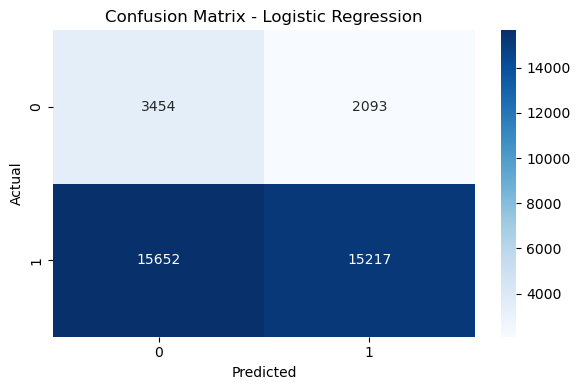

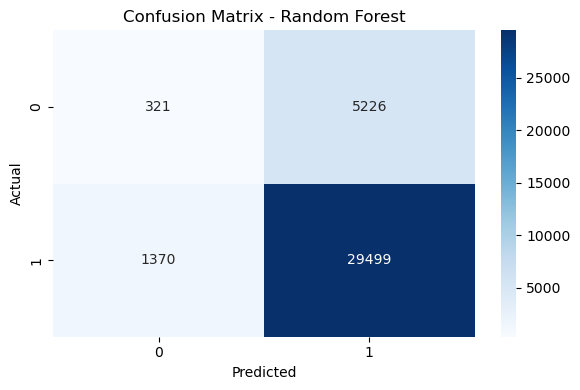

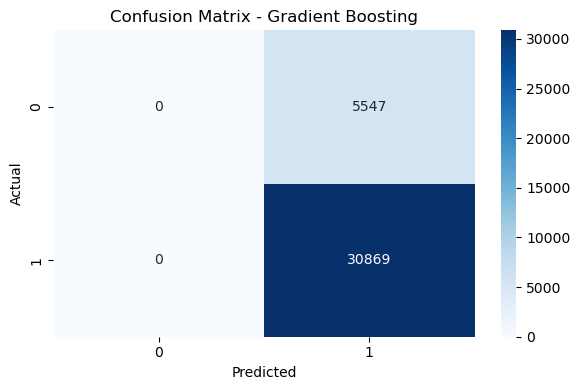

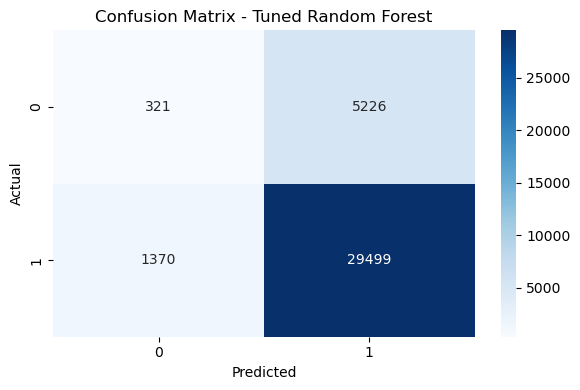

In [96]:
# Confusion matrix for each model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [97]:
# Cross-validation
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in trained_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV Mean F1": scores.mean(),
        "CV Std F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).set_index("Model")
print("=== Cross-Validation Results ===")
print(cv_results_df.round(4))


=== Cross-Validation Results ===
                     CV Mean F1  CV Std F1
Model                                     
Logistic Regression      0.6287     0.0041
Random Forest               NaN        NaN
Gradient Boosting        0.9176     0.0000
Tuned Random Forest         NaN        NaN


In [98]:
final_results = results_df.join(cv_results_df)
print("=== Final Model Assessment ===")
print(final_results.round(4))

=== Final Model Assessment ===
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  \
Model                                                                 
Logistic Regression    0.5127     0.8791  0.4930    0.6317   0.5839   
Random Forest          0.8189     0.8495  0.9556    0.8994   0.5446   
Gradient Boosting      0.8477     0.8477  1.0000    0.9176   0.5890   
Tuned Random Forest    0.8189     0.8495  0.9556    0.8994   0.5446   

                     CV Mean F1  CV Std F1  
Model                                       
Logistic Regression      0.6287     0.0041  
Random Forest               NaN        NaN  
Gradient Boosting        0.9176     0.0000  
Tuned Random Forest         NaN        NaN  


#### Insights on Assessing the Model

- The confusion matrix revealed that high performance metrics can be misleading in imbalanced datasets, as some models achieved strong scores while completely failing to detect the minority class.



## Final Model Selection

Based on the overall evaluation, the Random Forest model was selected as the final model. It offers the best balance between predictive performance and practical usability, correctly identifying both classes while maintaining strong overall metrics.